#### 1. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

#### 2.  Load the dataset

In [3]:
# Pima Indians Diabetes dataset — hosted publicly by Kaggle/UCI
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']

df = pd.read_csv(url, names=columns)

print(df.shape)        # how many rows and columns?
print(df.head())       # first 5 rows
print(df['Outcome'].value_counts())   # class balance — important!

(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigree  Age  Outcome  
0             0.627   50        1  
1             0.351   31        0  
2             0.672   32        1  
3             0.167   21        0  
4             2.288   33        1  
Outcome
0    500
1    268
Name: count, dtype: int64


 #### 3. Split into train / validation / test

In [4]:
X = df.drop('Outcome', axis=1)   # features
y = df['Outcome']                 # labels (0 = no diabetes, 1 = diabetes)

# First cut: hold out 15% as test set — lock it away now
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)

# Second cut: from the remaining 85%, take ~18% as validation (~15% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

Train:      537 samples
Validation: 115 samples
Test:       116 samples


#### 4. A naive baseline (the accuracy trap)

##### A model that predicts the majority class always achieves [majority class %] accuracy while being clinically useless.

In [5]:
# What if we just predicted "no diabetes" for everyone?
naive_predictions = np.zeros(len(y_val))  # all zeros = all "no diabetes"

naive_accuracy = accuracy_score(y_val, naive_predictions)
print(f"Naive model accuracy: {naive_accuracy:.2%}")
print(f"Class distribution in val set:\n{y_val.value_counts()}")

Naive model accuracy: 65.22%
Class distribution in val set:
Outcome
0    75
1    40
Name: count, dtype: int64


#### 5. First real classifier

In [6]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

val_preds = model.predict(X_val)

print(f"Logistic Regression accuracy:  {accuracy_score(y_val, val_preds):.2%}")
print(f"Precision: {precision_score(y_val, val_preds):.2%}")
print(f"Recall (Sensitivity): {recall_score(y_val, val_preds):.2%}")

Logistic Regression accuracy:  77.39%
Precision: 69.44%
Recall (Sensitivity): 62.50%


 #### 6. Confusion matrix visualised

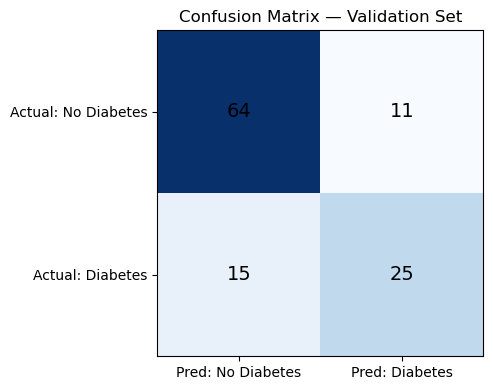

In [7]:
cm = confusion_matrix(y_val, val_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred: No Diabetes', 'Pred: Diabetes'])
ax.set_yticklabels(['Actual: No Diabetes', 'Actual: Diabetes'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14)

ax.set_title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.savefig('confusion_matrix_day1.png', dpi=150)
plt.show()

#### The validation set had 115 patients total: 75 healthy, 40 diabetic.
##### Top-left: 64 — True Negatives (TN)
75 healthy patients came in. The model correctly said "no diabetes" for 64 of them. These are the easy wins.
##### Top-right: 11 — False Positives (FP)
Those same 75 healthy patients — the model incorrectly flagged 11 of them as diabetic. They'd get an unnecessary follow-up. Worrying, but not dangerous.
##### Bottom-left: 15 — False Negatives (FN)
40 diabetic patients came in. The model missed 15 of them entirely — told them they were healthy and sent them home. This is the most dangerous box in clinical medicine.
##### Bottom-right: 25 — True Positives (TP)
The model correctly caught 25 of the 40 diabetic patients. These are the lives potentially helped.

## Real classifier

* Recall of 62.5% means the model missed 37.5% of diabetic patients. Out of the 40 diabetic patients in the validation set, roughly 15 walked away undetected.
* For a screening tool, that is still too many missed cases. A radiologist reading chest X-rays would want sensitivity above 90% for a screening task.
* Precision (69.44%) is higher than recall (62.50%). That means the model is more cautious about false alarms than it is about missed cases. For screening, you usually want the opposite — catch everything, even if it means some false alarms that get ruled out with a follow-up test.

1. Class distribution: 500 healthy (65%), 268 diabetic (35%) — moderately imbalanced
2. Naive model: 65.22% accuracy, 0% recall — looks acceptable, is clinically worthless
3. Logistic regression: better across all metrics, but still misses ~37.5% of diabetic cases

In [10]:
from IPython.display import display
import pandas as pd

metrics_data = {
    'Metric':    ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'Specificity'],
    'Formula':   ['(TP+TN) / all', 'TP / (TP+FP)', 'TP / (TP+FN)', 'TN / (TN+FP)'],
    'Calculation': ['(25+64) / 115', '25 / (25+11)', '25 / (25+15)', '64 / (64+11)'],
    'Result':    ['77.4%', '69.4%', '62.5%', '85.3%']
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.style.set_caption("Model Evaluation Metrics")
                        .set_properties(**{'text-align': 'center'})
                        .set_table_styles([
                            {'selector': 'caption', 
                             'props': [('font-size', '14px'), 
                                       ('font-weight', 'bold'),
                                       ('text-align', 'center')]},
                            {'selector': 'th', 
                             'props': [('background-color', '#2c3e7a'),
                                       ('color', 'white'),
                                       ('text-align', 'center')]}
                        ]))

,Metric,Formula,Calculation,Result
0,Accuracy,(TP+TN) / all,(25+64) / 115,77.4%
1,Precision,TP / (TP+FP),25 / (25+11),69.4%
2,Recall (Sensitivity),TP / (TP+FN),25 / (25+15),62.5%
3,Specificity,TN / (TN+FP),64 / (64+11),85.3%
